## D213 Task 2: Sentiment Analysis Using Neural Networks

Advanced Data Analytics - D213
<br> 
Sentiment Analysis Using Neural Networks
<br> 
Instructor: Dr. William Sewell
<br> 
Student Name: Devon E. Johnson
<br> 
Student ID: 011494484
<br> 
Email: djo3593@wgu.edu
<br> 

### Table of Contents

* [A1: Research Question](#A1:-Research-Question)
* [A2: Analysis Goal](#A2:-Analysis-Goal)
* [A3: Neural Network Identification](#A3:-Neural-Network-Identification)
* [B1: Exploratory Data Analysis](#C1:-Exploratory-Data-Analysis)
* [B2: Goals of Tokenization](#B2:-Goals-of-Tokenization)
* [B3: Padding Process](#B3:-Padding-Process)
* [B4: Categories of Sentiment](#B4:-Categories-of-Sentiment)
* [B5: Data Preparation](#B5:-Data-Preparation)
* [B6: Cleaned Data Set](#B6:-Cleaned-Data-Set)
* [C1: Output of Model Summary](#C1:-Output-of-Model-Summary)
* [C2: Layers and Parameters](#C2:-Layers-and-Parameters)
* [C3: Justification of Hyperparameters](#C3:-Justification-of-Hyperparameters)
* [D1: Impact of Stopping Criteria](#D4:-Impact-of-Stopping-Criteria)
* [D2: Model Fitness](#D2:-Model-Fitness)
* [D3: Training Visualizations](#D3:-Training-Visualizations)
* [D4: Predictive Accuracy](#D4:-Predictive-Accuracy)
* [E: Code Used to Save Trained Network](#E:-Code-Used-to-Save-Trained-Network)
* [F: Functionality](#F:-Functionality)
* [G: Recommended Course of Action](#G:-Recommended-Course-of-Action)
* [H: Interactive Development Environment](#H:-Interactive-Development-Environment)
* [I: Code References](#I:-Code-References)
* [J: Source References](#J:-Source-References)

### A1: Research Question

Movie reviews are among the most common forms of unstructured opinion data available online, yet most analytical tools require some kind of structured input, usually a star rating, to classify sentiment. This project investigates whether a Long Short-Term Memory Network (LSTM) can predict whether a viewer would recommend a film based solely on the text of their IMDB review. If successful, this approach could scale to platforms where structured ratings don't exist, like comment sections on YouTube, Reddit threads, or Twitter replies.

### A2: Analysis Goal

The goal of the analysis is to build a neural network to automate sentiment analysis that achieves a test accuracy of at least 70% with no significant overfitting to the training data ("Which is more important: Model performance or model accuracy?," 2026). Performance will be evaluated using accuracy, precision, and recall after splitting the data into training, validation, and test sets.

### A3: Neural Network Identification

Recurrent Neural Networks (RNNs) are a class of neural networks designed to process sequential data by retaining information from previous steps. In the case of text, an RNN can use the context of a previous word to inform the context of the next word. Standard RNNs lose efficiency as sequences grow longer, as they lose the context of earlier words. LSTM is a specific type of RNN designed to overcome this limitation by using memory cells and gating mechanisms to selectively retain and forget information over time. The built-in memory state allows LSTMs to retain information for extended periods ("Using machine learning for sentiment analysis: A deep dive," 2025).

I specifically chose to use a bidirectional LSTM for this project. Bi-LSTMs consist of two LSTM layers, one processing in the forward direction and the other in the backward direction, which allows it to process text in both directions at once (Anishnama, 2023). Since reviews can contain layered context where succeeding words may inform the overall context just as much as preceding words, this felt like the best fit for the project.

### B1: Exploratory Data Analysis

**1. Duplicate Reviews:** This is not requested for this portion, but I will check for duplicate reviews. A lack of sufficient variety might lead to overfitting in the final model. 

**2.  Presence of unusual characters (e.g., emojis, non-English characters):** This will be evaluated using a compiled regex pattern, with the associated code adapted from Github (Bidap, 2020). For non-English characters, I will use Python's isascii() method to specifically identify characters outside the standard ASCII range ("Python string isascii() method," n.d.).

**3.  Vocabulary Size:** I will tokenize the dataset with Tokenizer from keras and count the number of unique tokens, representing words in this case. I will provide the total number of words, as well as the total number of unique tokens and print the 20 most commonly found words . 

**4. Proposed Word Embedding Length:** I will re-address this after determining vocabulary size.

**5. Statistical Justification for the Chosen Maximum Sequence Length:** I will readdress this after analyzing the distribution of sentence lengths. 

In [2]:
import pandas as pd
import numpy as np

file_path = r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D213/imdb_labelled.txt'

lists = []
with open(file_path, 'r', encoding='utf-8') as data_file:
    for line in data_file:
        data = line.strip().split('\t') 
        lists.append(data)

df = pd.DataFrame(lists, columns=['review', 'sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print(f"Dataset loaded: {df.shape}")
df.info(memory_usage='deep')
print(f"Positive reviews: {(df['sentiment'] == 1).sum()}")
print(f"Negative reviews: {(df['sentiment'] == 0).sum()}")

Dataset loaded: (1000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     1000 non-null   object
 1   sentiment  1000 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 132.4 KB
Positive reviews: 500
Negative reviews: 500


In [3]:
# Look for duplicates
print(f"\nDuplicate reviews: {df.duplicated().sum()}")
duplicates = df[df.duplicated(keep=False)]
print(duplicates.sort_values('review'))


Duplicate reviews: 3
                               review  sentiment
125                           10/10            1
788                           10/10            1
90   Definitely worth checking out.            1
363  Definitely worth checking out.            1
572                Not recommended.            0
585                Not recommended.            0


Here we see that there aren't many duplicate reviews, and certainly not so many that we would see overfitting in our model due to insufficient variety. Indeed, these reviews are so generalized, that they might not be true duplicates but different viewers having the same takeaway.

In [4]:
import re
import string

# Check for emojis (Bidap, 2020)
def contains_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return bool(emoji_pattern.search(str(text)))

# Check for non-English characters ("Python string isascii() method," n.d.) 
def contains_non_english(text):
    return not str(text).isascii()

df['emoji'] = df['review'].apply(contains_emoji)
df['non_english'] = df['review'].apply(contains_non_english)

print("\nUnusual Character Analysis:")
print(f"Reviews with emojis: {df['emoji'].sum()}")
print(f"Reviews with non-English characters: {df['non_english'].sum()}")


Unusual Character Analysis:
Reviews with emojis: 0
Reviews with non-English characters: 13


In [5]:
# Find all non-ASCII characters
non_english = set()
for review in df['review']:
    non_english.update(c for c in review if not c.isascii())

for idx, review in df[df['non_english']]['review'].items():  # .items() gives you the index
    non_ascii_chars = [c for c in review if not c.isascii()]
    print(f"Row {idx}: {review[:500]}")
    print(f"Non-ASCII chars: {non_ascii_chars}\n")

Row 18: It's practically perfect in all of them  a true masterpiece in a sea of faux "masterpieces.  
Non-ASCII chars: ['\x96']

Row 80: I'm glad this pretentious piece of s*** didn't do as planned by the Dodge stratus Big Shots... It's gonna help movie makers who aren't in the very restrained "movie business" of Québec.  
Non-ASCII chars: ['é']

Row 178: The script iswas there a script?  
Non-ASCII chars: ['\x85']

Row 182: I'll even say it again  this is torture.  
Non-ASCII chars: ['\x96']

Row 424: This show is made for Americans - it is too stupid and full with hatred and clichés to be admitted elsewhere.  
Non-ASCII chars: ['é']

Row 469: A cheap and cheerless heist movie with poor characterisation, lots of underbite style stoic emoting (think Chow Yun Fat in A Better Tomorrow) and some cheesy clichés thrown into an abandoned factory ready for a few poorly executed flying judo rolls a la John Woo.  
Non-ASCII chars: ['é']

Row 495: And I forgot: The Casting here i superb, with

Here we see that no emojis were detected, but there were 13 reviews with non-English characters. Looking at those reviews, eight of these were non-printable characters, likely derived from an issue during the text encoding conversion, and five were accented letters used legitimately.

We do not need to conduct a manual character removal, since Keras Tokenizer's default *filters* parameter automatically removes punctuation during tokenization and will eliminate the non-printable characters. The accented letters are treated as standard vocabulary tokens and will be preserved. 

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Clean and prepare text
df['review'] = df['review'].str.lower()

# Extract vocabulary (Balantekin, 2024)
words = {word for review in df['review'] for word in review.split()}
vocab_size = len(words)

# Tokenize using Keras
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['review'])

# Get word counts
word_counts = tokenizer.word_counts
total_words = sum(word_counts.values())

print(f"Total words (Tokens): {total_words:,}")
print(f"Unique Words (Vocabulary Size): {vocab_size:,}")

# Top 20 words
print(f"\nTop 20 Most Frequent Words:")
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (word, count) in enumerate(sorted_words, 1):
    print(f"  {i}. {word}: {count}")

Total words (Tokens): 14,481
Unique Words (Vocabulary Size): 4,007

Top 20 Most Frequent Words:
  1. the: 848
  2. and: 434
  3. a: 433
  4. of: 377
  5. is: 339
  6. this: 292
  7. i: 270
  8. it: 256
  9. to: 253
  10. in: 203
  11. was: 185
  12. movie: 181
  13. film: 159
  14. that: 156
  15. for: 105
  16. as: 94
  17. but: 93
  18. with: 90
  19. one: 78
  20. on: 76


**4. Proposed Word Embedding Length:** Here we see that there are 14,481 total words in the dataset, with 4,007 unique words representing the actual vocabulary size. Since we have a vocabulary size under 10,000, we will use a word embedding size of **100**, to give us a good balance of capturing word meanings without overfitting ("How do I choose the right dimensionality for my vector embeddings?," n.d.). 

Sequence Length Statistics:
  Mean: 14.48
  Median: 12
  Max: 73
  75th percentile: 19
  90th percentile: 27
  95th percentile: 33
  99th percentile: 45

Coverage Analysis:
  Max length 50: 99.3% coverage
  Max length 75: 100.0% coverage
  Max length 100: 100.0% coverage
  Max length 150: 100.0% coverage
  Max length 200: 100.0% coverage


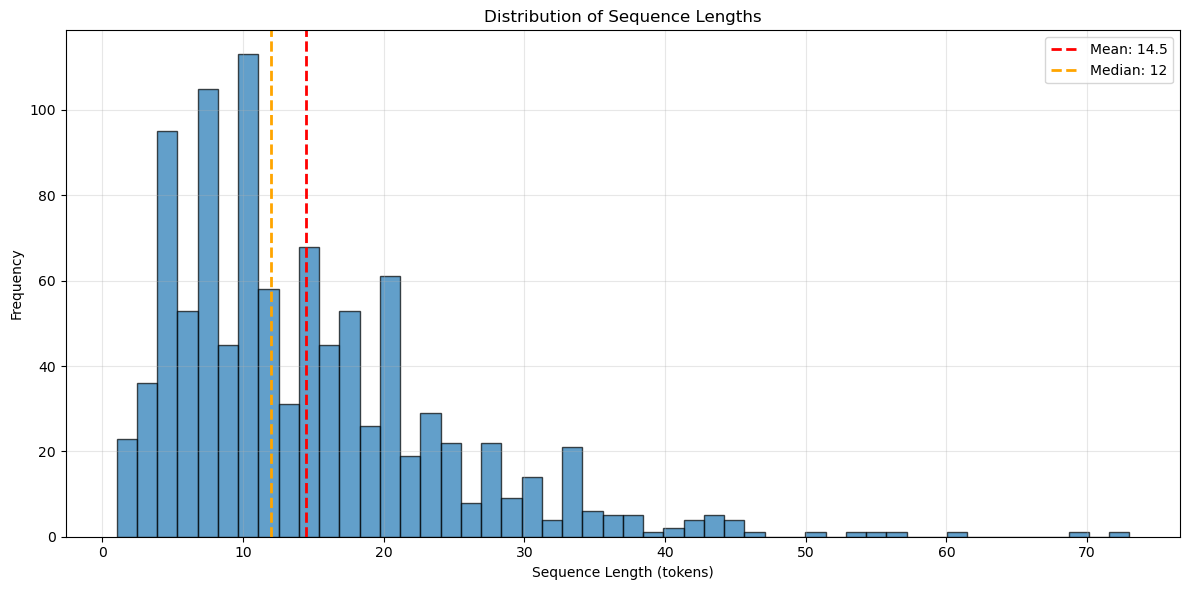

In [7]:
import matplotlib.pyplot as plt

# Tokenize and get sequence lengths (Balantekin, 2024)
sequences = tokenizer.texts_to_sequences(df['review'])

# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in sequences]

# Statistics
print(f"Sequence Length Statistics:")
print(f"  Mean: {np.mean(sequence_lengths):.2f}")
print(f"  Median: {np.median(sequence_lengths):.0f}")
print(f"  Max: {max(sequence_lengths)}")
print(f"  75th percentile: {np.percentile(sequence_lengths, 75):.0f}")
print(f"  90th percentile: {np.percentile(sequence_lengths, 90):.0f}")
print(f"  95th percentile: {np.percentile(sequence_lengths, 95):.0f}")
print(f"  99th percentile: {np.percentile(sequence_lengths, 99):.0f}")

# Coverage analysis for different max lengths
print(f"\nCoverage Analysis:")
for max_len in [50, 75, 100, 150, 200]:
    coverage = sum(1 for length in sequence_lengths if length <= max_len) / len(sequence_lengths) * 100
    print(f"  Max length {max_len}: {coverage:.1f}% coverage")

# Histogram
plt.figure(figsize=(12, 6))
plt.hist(sequence_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(sequence_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(sequence_lengths):.1f}')
plt.axvline(np.median(sequence_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(sequence_lengths):.0f}')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sequence_length_histogram.png', dpi=300)
plt.show()

**5. Statistical Justification for the Chosen Maximum Sequence Length:** Given the results, the best option appears to be a maximum sentence length of 75 tokens. This will capture 100% of reviews, since the longest review contains 73 tokens. This is well-above the 99th percentile with 45 tokens, ensuring that even outlier-length reviews are included in the final model. The histogram also shows that most of the reviews cluster below 30 tokens, showing that a sentence length of 75 tokens should be sufficient for retaining all of the data.

### B2: Goals of Tokenization

Tokenization converts raw text into smaller units, called tokens, that can be processed by a neural network, splitting review text into individual words, normalizing all the text by converting to lowercase and removing punctuation, and mapping unique words to integer indices to build a vocabulary ("Tokenization in NLP," 2025;  "Tokenization Vs lemmatization," n.d.). The dataset was already tokenized when we generated the vocabulary size, but the code below demonstrates an example of how tokenization changes the format of the review text, using the *text_to_word_sequence* function of the *tensorflow.keras.preprocessing.text* package: 

In [8]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sample_review = df['review'].iloc[0]
result = text_to_word_sequence(sample_review)
print(f"Original: {sample_review}")
print(f"Tokenized: {result}")

Original: a very, very, very slow-moving, aimless movie about a distressed, drifting young man.  
Tokenized: ['a', 'very', 'very', 'very', 'slow', 'moving', 'aimless', 'movie', 'about', 'a', 'distressed', 'drifting', 'young', 'man']


### B3: Padding Process

Padding is the process of standardizing sentence lengths by adding zeroes to reviews, thus ensuring that all input sequences have uniform lengths to be processed by the neural network, since neural networks require fixed-size inputs (Aly, n.d.). Since our reviews vary in length from 1 to 73 tokens, padding is used to extend shorter sequences to the predetermined length of 75 tokens. Pre-padding, when padding is added at the beginning of a sequence, will be used because it is the natural choice when working with LSTMs since it allows the model to focus on the actual sequence data first (Sohail, 2024).

The code below was used to conduct the padding process, as well as print an example of a padded sequence: 

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Apply pre-padding ("pad_sequences," n.d.)
max_seq_length = 75
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding = 'pre', truncating='post')

print(f"Padded sequence:\n{padded_sequences[0]}")

Padded sequence:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    3   26   26   26  286  406 1216   12   35
    3 1217 1218  407  141]


### B4: Categories of Sentiment

There are only two possible sentiment outcomes in this dataset: positive (1) or negative (0). When dealing with binary classification, the sigmoid function is among the most commonly used activation functions. This function always returns a value between 0 and 1, which can then be interpreted as a probability. 

For instance, if the model outputs a value of 0.3, the sigmoid function can translate that value into a probability of a 30% chance that the input belongs to class 1 and a 70% chance that it belongs in class 0. The model then chooses the class with the highest probability. 

The sigmoid function has strong advantages, mainly in its ability to interpret predictions as probabilities and to reflect small changes in input to output, which helps the model learn continuously during training. However, when there are too many outlier inputs, the sigmoid function tends to saturate, causing the gradient to become almost zero and leading to a *vanishing gradient* problem, which makes it difficult for the model to properly learn (Amit, 2024).

In this case, our LSTM network will help to mitigate any issues that might emerge from a vanishing gradient, since LSTMs were specifically designed to overcome this challenge by using the gating mechanisms previously discussed, which control the flow of information and gradients. This should allow the model to continue learning and retaining information even in the presence of outliers (Xu, 2024).

### B5: Data Preparation

* Imported all the IMDB reviews by review and sentiment
  
* Used tab-delimited parsing with *line.strip().split('\t')* to handle formatting issues, specifically removing a leading quotation mark at the beginning of the 20th review (*" The structure of this film is easily the most tightly constructed in the history of cinema.*)

* Checked the size and shape of the dataset, as well as the respective datatypes for review and sentiment

* Checked for duplicate reviews (only found three, not an issue that needed to be addressed or considered later in data analysis).

* Checked for emojis using a compiled regex pattern, with the associated code adapted from Github (Bidap, 2020). Found no reviews with emojis.

* Checked for non-English characters using Python's *isascii()* method to specifically identify characters outside the standard ASCII range ("Python string isascii() method," n.d.). Found 13 reviews with non-ASCII characters.

* Printed the reviews containing non-English characters to more thoroughly investigate the types of characters present - identified eight non-printable characters from a likely text encoding conversion issue and five accented characters used in a legitimate sense.

* Imported tensorflow and used the *Tokenizer* class from the *tensorflow.keras.preprocessing.text* module to tokenize the dataset and check the total number of words used in the dataset, as well as the number of unique words that represent the size of the vocabulary. Printed the top 20 used words.

* Selected a word embedding size of 100 based on the vocabulary size being 4,007, well under 10,000 ("How do I choose the right dimensionality for my vector embeddings?," n.d.).

* Used *Tokenizer* to extract the sequence lengths of the reviews and calculate the lengths to perform a statistical assessment of the mean, median, and max size of the sequence lengths, as well as the respective sizes at the 75th, 90th, 95th, and 99th percentiles, with a coverage analysis of the max length at those different percentiles. Also generated a histogram showing the distribution of sequence lengths. All of this showed that a sequence length of 75 was the ideal choice, as it covered the maximum sequence length of 73 and showed 100% coverage at the max length of 75.

* Printed an example of a tokenized sentence to double-check the tokenization performance. Tokenizing the dataset accomplished a great deal of our test pre-processing by lowercasing all of the text and removing punctuation.

* We skipped lemmatization because our dimensionality is already reasonably low, and it does not seem like a beneficial step in this scenario.

* We skipped the removal of stop words because we are working with an LSTM network that can grasp the grammatical context of those words (Gardiner, 2025).

* Executed pre-padding to standardize sequence length, using the *pad_sequences* function of the *tensorflow.keras.preprocessing.sequence* package to add zeroes at the beginning of shorter sentences to ensure they all matched the standardized length of 75 tokens.

* Now we need to split the data into training, testing, and validation data, first splitting it into 80% training data and 20% testing data, then splitting the 20% test data into 10% validation and 10% test. The code for this is below.

* Finally, we will save copies of the cleaned train, test, and validation datasets. 

In [10]:
from sklearn.model_selection import train_test_split

# Prepare X and y
X = padded_sequences
y = df['sentiment'].values

# Split: 80% train, 20% remaining
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, train_size=0.8, random_state=42)

# Split remaining 20% into 10% validation, 10% test (Mistry, 2025)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape} | Sentiment distribution: {np.bincount(y_train)}")
print(f"Validation set: {X_val.shape} | Sentiment distribution: {np.bincount(y_val)}")
print(f"Test set: {X_test.shape} | Sentiment distribution: {np.bincount(y_test)}")

Training set: (800, 75) | Sentiment distribution: [409 391]
Validation set: (100, 75) | Sentiment distribution: [53 47]
Test set: (100, 75) | Sentiment distribution: [38 62]


### B6: Cleaned Data Set

In [11]:
# Save training set
train_df = pd.DataFrame(X_train)
train_df['sentiment'] = y_train
train_df.to_csv('train_data.csv', index=False)

# Save validation set
val_df = pd.DataFrame(X_val)
val_df['sentiment'] = y_val
val_df.to_csv('validation_data.csv', index=False)

# Save test set
test_df = pd.DataFrame(X_test)
test_df['sentiment'] = y_test
test_df.to_csv('test_data.csv', index=False)

### C1: Output of Model Summary

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

import warnings
import random

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Model parameters (Brownlee, 2021)
word_index_size = len(tokenizer.word_index) + 1
embed_dim = 100
max_review_length = max_seq_length

from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(Embedding(input_dim=word_index_size, output_dim=embed_dim, input_length=max_review_length))
model.add(Bidirectional(LSTM(units=64, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(units=1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

# Build the model explicitly
model.build(input_shape=(None, max_review_length))

# Display model summary
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 75, 100)        │       313,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,009 (1.52 MB)

 Trainable params: 398,009 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

None


### C2: Layers and Parameters

The model summary shows three layers with 398,009 total trainable parameters:

**Embedding Layer: 313,400 parameters**

The embedding layer converts integer word indices into 100-dimensional dense vectors, reducing the high-dimensional input into a lower-dimensional vector. Here we see that the layer learned vector representations for 4,007 unique words, with each review padded or truncated to 75 tokens (Yadav, 2024).

**Bidirectional LSTM Layer: 84,480 parameters**

As discussed in A3, bi-LSTMs process text in both forward and backward directions simultaneously, allowing the model to capture layered context from both preceding and succeeding words. Here, the layer contains 64 LSTM units in each direction (forward and backward), outputting 128 combined features (Taparia, 2026).

**Dense Layer: 129 parameters**

Also known as the fully connected or feed-forward layer, the dense layer uses the sigmoid activation function to connect every neuron from the previous layer to every neuron in the current layer (Agarwal et al., 2020; Sharma, 2025). Here, the layer condenses the 128 LSTM outputs into one probability score ranging from 0 to 1. 

### C3: Justification of Hyperparameters

• **Activation functions:** Two activation functions were used in the model. A sigmoid activation function was used in the dense layer, as discussed previously. Additionally, LSTM inherently uses Tanh activation to squeeze input data to a range between -1 and 1 to stabilize the network and prevent the explosion or vanishing of gradients ("What is the intuition of using tanh in LSTM?," n.d.). 

• **Number of Nodes per Layer:** The embedding layer was set to 100 nodes based on the vocabulary size of 4,007 words. The bi-LSTM layer was configured with 64 nodes per direction, for a total of 128 nodes. Finally, the dense layer contained only one node, since binary classification requires a single output neuron to represent the probability of the input belonging to the “positive” class (Prosise, 2021). 

• **Loss Function:** Binary cross-entropy (BCE) was selected as the loss function, since it is specifically designed for binary classification problems. BCE quantifies the difference between the actual class labels (0 or 1) and the predicted probabilities. Lower BCE values indicate better predictive power, while the BCE value increases as predictions drift further from actual outcomes (Franco, 2025).

• **Optimizer:** Adaptive Moment Estimation (ADAM) optimizer was used because it leverages the advantages  of other algorithms by automatically adjusting the learning rate for each parameter during training, combining the benefits of momentum and adaptive learning rates. This helps the model learn faster early in training and slow down as it approaches the best parameters, thus preventing overshooting ("Advanced optimization: Understanding and implementing ADAM," n.d.).

• **Stopping Criteria:** Early stopping, a regularization method that stops training once the model’s performance on the validation dataset stops improving, will be implemented to prevent overfitting ("What is early stopping in deep learning?," 2024). This will be discussed further in the next section. 

• **Evaluation Metric:** I used the *BinaryAccuracy* class from *Keras*, since we are dealing with a binary classification problem (Keras Team, n.d.). The model will be evaluated with a target test accuracy of at least 70%, and additional metrics, such as precision, recall, and F-1 score, will also be calculated to better assess the model's overall performance. I will also calculate the loss gap between the validation and training results to see if the model ended up overfitting to the training data rather than actually learning the context of the review text.

### D1: Impact of Stopping Criteria

Early stopping is a regularization technique used to stop training once the model shows signs of overfitting, thus saving computational resources and improving model efficiency and performance  ("Regularization by early stopping," 2025).

I will implement early stopping using the *EarlyStopping* class from *tensorflow.keras.callbacks*. The validation loss will be monitored with a patience of 3 epochs, meaning training will halt if validation loss fails to improve for 3 consecutive epochs. In order to ensure that the model reverts to the checkpoint with the highest validation performance, I will set restore_best_weights to True (Keras Team, n.d.). 

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1) #(Keras Team, n.d.)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - binary_accuracy: 0.5263 - loss: 0.6922 - val_binary_accuracy: 0.5600 - val_loss: 0.6906
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - binary_accuracy: 0.7063 - loss: 0.6614 - val_binary_accuracy: 0.6300 - val_loss: 0.6649
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - binary_accuracy: 0.8087 - loss: 0.5052 - val_binary_accuracy: 0.7200 - val_loss: 0.5533
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - binary_accuracy: 0.8925 - loss: 0.2857 - val_binary_accuracy: 0.7500 - val_loss: 0.4949
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - binary_accuracy: 0.9588 - loss: 0.1491 - val_binary_accuracy: 0.7700 - val_loss: 0.4992
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - binary_accuracy: 0.9775 - loss: 0.0943 - val_binary_accuracy: 0.7300 - val_loss: 0.5998
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - binary_accuracy: 0.9787 - loss: 0.0738 - val_binary_accuracy: 0.7300 - val_loss: 0.5978
Epoch 7: earl

I set the callback to train for a maximum of 50 epochs, and training ended up stopping at the seventh epoch, with the fourth epoch selected as the best epoch with the lowest validation loss. The fourth epoch demonstrated a final training accuracy of 89.25%, final validation accuracy of 75%, and a validation loss of 0.4949. After the fourth epoch, validation loss continued to increase, rising to 0.4992 at the fifth epoch, 0.5998 at the sixth epoch, and 0.5978 at the seventh epoch, so model weights were restored from the fourth epoch. 

### D2: Model Fitness

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

final_epoch = len(history.history['loss']) - 1
train_acc = history.history['binary_accuracy'][final_epoch]
val_acc = history.history['val_binary_accuracy'][final_epoch]

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - binary_accuracy: 0.7400 - loss: 0.5445

Test Accuracy: 0.7400
Training Accuracy: 0.9787
Validation Accuracy: 0.7300


In [15]:
warnings.filterwarnings('ignore')

# Predict on first 5 test reviews
sample_predictions = model.predict(X_test[:5])
print("Predicted probabilities:", sample_predictions.flatten())
print("Predicted classes:", np.rint(sample_predictions).flatten().astype(int))
print("Actual labels:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
Predicted probabilities: [0.0797044  0.93087673 0.4778729  0.5836185  0.59793085]
Predicted classes: [0 1 0 1 1]
Actual labels: [1 1 1 1 1]


The model achieved a test accuracy of 74.00%, only slightly higher than the target of 70%. The training accuracy was much higher at 97.87%, and the validation accuracy was slightly lower at 73%. This indicates that the model overfit to the training data. To investigate the extent of overfitting, I calculated the accuracy gap between training and validation data as well as the loss gap between training and validation results.

In [16]:
# Check final epoch performance
final_epoch = len(history.history['loss']) - 1
train_acc = history.history['binary_accuracy'][final_epoch]
val_acc = history.history['val_binary_accuracy'][final_epoch]
train_loss = history.history['loss'][final_epoch]
val_loss = history.history['val_loss'][final_epoch]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Accuracy Gap between Validation and Training: {(train_acc - val_acc)*100:.2f}%")
print(f"\nFinal Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Loss Gap between Validation and Training: {val_loss - train_loss:.4f}")

Final Training Accuracy: 0.9787
Final Validation Accuracy: 0.7300
Accuracy Gap between Validation and Training: 24.87%

Final Training Loss: 0.0738
Final Validation Loss: 0.5978
Loss Gap between Validation and Training: 0.5240


The accuracy gap between the training and validation data was 24.87%. Meanwhile, the final training loss was 0.0738, and the final validation loss was 0.5978, yielding a loss gap of 0.5240. The validation set was specifically implemented to provide an unbiased evaluation of the model during the training phase, so we compare this metric to the training data when evaluating the model's overall fitness ("The differences between training, validation & test datasets," 2026) . 

This accuracy gap shows that the model is definitely overfitting to the training data, making errors on fewer than 3% of reviews that it has seen before, but struggling more substantially on previously unseen reviews. This is reinforced by the loss metrics, which again show good accuracy on the training data but poor performance and uncertainty on the validation data. 

I took several steps to mitigate overfitting, including limiting the embedding dimension to 100 and implementing early stopping, as discussed earlier. It is not shown here, but when I first compiled my model, the overfitting metrics were actually far worse, so I retroactively applied 20% dropout and 20% recurrent dropout within the bi-LSTM layer. Dropout is a regularization technique specifically designed to address overfitting by randomly deactivating neurons during training. This artificially creates many smaller, less complex networks, which forces the model to avoid reliance on a single neuron and to “learn” the training data rather than just memorize connections (Vij, 2023). I chose a moderate rate of 20% in an attempt to balance accuracy with overfitting, but ended up losing too much accuracy with anything over 20%, still leaving the issue of overfitting.

As such, even though the model nominally met the accuracy goal, the overfitting issue still makes it unsuitable for actual use and real-world deployment. 

### D3: Training Visualizations

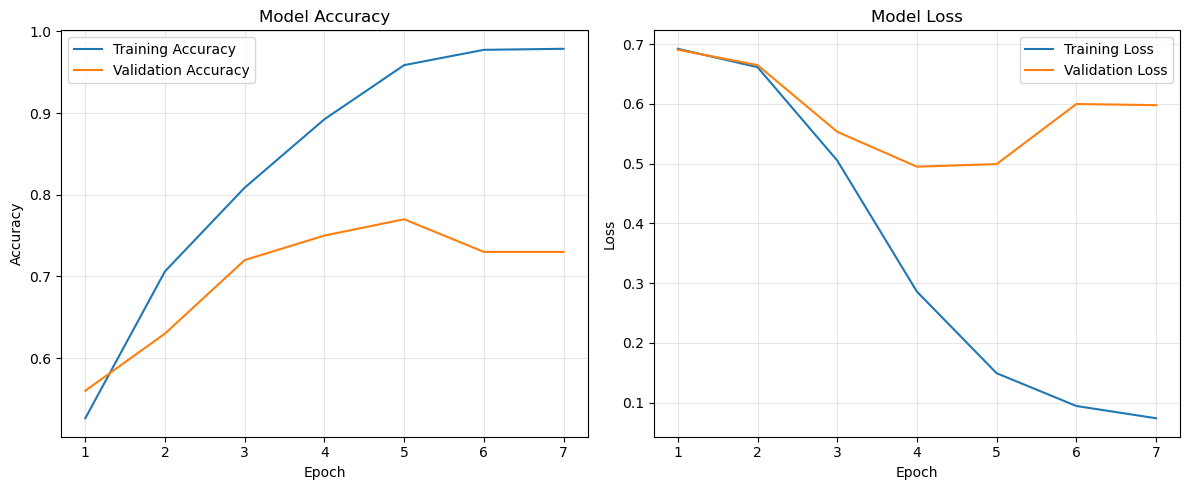

In [17]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
epochs_range = range(1, len(history.history['binary_accuracy']) + 1)
plt.plot(epochs_range, history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
epochs_range = range(1, len(history.history['binary_accuracy']) + 1)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### D4: Predictive Accuracy

As discussed in section D2, the model achieved training accuracy of 97.87%, validation accuracy of 73.00%, and test accuracy of 74%, with an accuracy gap of 24.87% and a loss gap of 0.5240 between the training and validation results.

The accuracy and model loss plots in D3 visually demonstrate these metrics, showing that the accuracy lines track relatively closely together up to the third epoch, but then diverge sharply, with the training accuracy continuing in an upward direction and the validation accuracy peaking at epoch 4, then gradually declining from there to the seventh epoch. Meanwhile, the training and validation losses remain consistent through to the second epoch, after which they begin drifting further apart, finally settling with the validation loss at approximately 0.60 and the training loss at approximately 0.08. On the graph, the validation loss line forms a distinct "U" shape, showing that the model really only memorized the training material and did not learn to actually recognize patterns.

I will also generate a confusion matrix as well as precision and recall metrics, to fully evaluate the model's performance:

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 


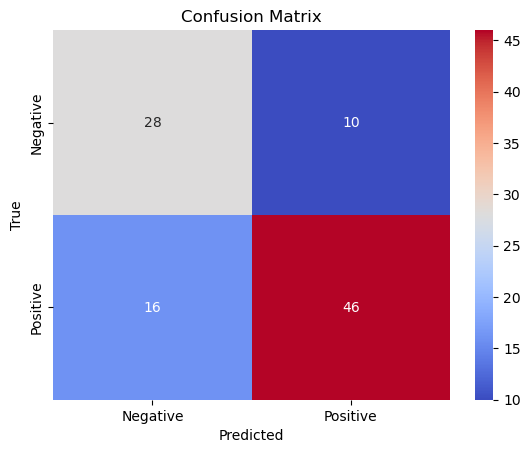

Confusion Matrix:
True Negatives: 28 (28.00%)
False Positives: 10 (10.00%)
False Negatives: 16 (16.00%)
True Positives: 46 (46.00%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.74      0.68        38
    Positive       0.82      0.74      0.78        62

    accuracy                           0.74       100
   macro avg       0.73      0.74      0.73       100
weighted avg       0.75      0.74      0.74       100


Test Accuracy: 0.7400


In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Generate predictions
y_pred = model.predict(X_test)
y_pred = np.rint(y_pred)

# Generate Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
class_labels = ['Negative', 'Positive']

# Plot
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='coolwarm', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print details
print("Confusion Matrix:")
total = conf_mat.sum()
print(f"True Negatives: {conf_mat[0,0]} ({conf_mat[0,0]/total*100:.2f}%)")
print(f"False Positives: {conf_mat[0,1]} ({conf_mat[0,1]/total*100:.2f}%)")
print(f"False Negatives: {conf_mat[1,0]} ({conf_mat[1,0]/total*100:.2f}%)")
print(f"True Positives: {conf_mat[1,1]} ({conf_mat[1,1]/total*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Accuracy
accuracy = (conf_mat[0][0] + conf_mat[1][1]) / conf_mat.sum()
print(f"\nTest Accuracy: {accuracy:.4f}")

The confusion matrix shows that the model correctly identified 28 negative sentiment reviews and 46 positive sentiment reviews, but incorrectly identified 10 negative reviews as positive and 16 positive reviews as negative, leading to an overall test accuracy of 74%.

Additionally, the precision scores show that the model is able to accurately predict negative sentiment 64% of the time, and accurately predict positive sentiment 82% of the time, showing it is better able to predict positive sentiment, potentially because the model contained more positive examples than negative (62 positive vs 38 negative reviews as shown in the *support* column of the classification report) to learn from in the first place. However, the recall scores show that the model correctly identifies 74% of both negative and positive reviews ("Classification: Accuracy, recall, precision, and related metrics," n.d.).

Overall, we can clearly see that the model performs better when predicting positive sentiment than negative sentiment in terms of precision - when it predicts positive, it's correct 82% of the time versus only 64% for negative predictions. Overall, the metrics indicate that while the model displays equal recall in its ability to detect both classes, it is still more likely to misclassify negative reviews as positive when faced with words or context on which it hasn’t been sufficiently trained. 

### E: Code Used to Save Trained Network

In [19]:
# Save model
model_file_name = "sentiment_model.keras"
model.save(model_file_name)
print(f"Model successfully saved as {model_file_name}")

Model successfully saved as sentiment_model.keras


### F: Functionality

In my honest opinion, this model is not something I would want to release as a product as is, so I would not classify it as fully functional. While it achieved the threshold of 70% test accuracy, achieving 74%, this was not a very high bar to begin with and the model still exhibited significant issues with overfitting despite the many mitigating steps I took to prevent that issue from occurring in the first place, e.g. using a relatively low embedding dimension, setting dropout and recurrent dropout rates to 20%, and implementing early stopping. 

The classification report and confusion matrix show that the model is worse at correctly predicting negative sentiment than positive sentiment, likely stemming from the data imbalance between positive and negative sentiment reviews and worsened by the model’s demonstrated poor fit. 

In terms of the network architecture, it is likely that the model’s complexity led to its issues in attaining a balance between accuracy and fit. 398,009 parameters are far excessive for a 1,000-review dataset and are likely to have significantly exacerbated overfitting. I will address this in the next section, where I discuss the recommended course of action. 

### G: Recommended Course of Action

I suggest first attempting to tweak the current model to reduce the number of parameters. I would reduce the LSTM units from 64 to 32 per direction, reducing the BiLSTM output from 128 to 64 features. Additionally, I would try reducing the embedding dimensions from 100 to 50. Since our vocabulary size is relatively small at 4,007 words, 100 dimensions might still provide more capacity than necessary.

If these measures don't work, I would also suggest trying the model on a larger dataset, since there might simply not be enough training data in the 80%, 10%, 10% split across 1,000 reviews to allow the model to actually learn context and meaning. I could convert other IMDB reviews to CSV format and try the model again on increasingly larger datasets to see if the accuracy and loss gaps narrow.

### H: Interactive Development Environment

This report is provided in a Jupyter Notebook to satisfy the requirement of using an industry-relevant interactive development environment.

### I: Code References

Balantekin, B. (2024, October 14). Deep learning and NLP for text analytics: Step-by-step guide to building a text classification system. Medium. 

https://medium.com/@balantekinbgr/deep-learning-and-nlp-for-text-analytics-step-by-step-guide-to-building-a-text-classification-b35349e6cdb1

Bidap, A. (2020, October 19). AI-based social media caption generator. GitHub. 

https://github.com/aashish-bidap/AI-based-Social-Media-Caption-Generator

Brownlee, J. (2021, January 17). How to develop a bidirectional LSTM for sequence classification in Python with Keras. MachineLearningMastery.com. 

https://machinelearningmastery.com/develop-bidirectional-lstm-sequence-classification-python-keras/

Brownlee, J. (2022, August 5). Display deep learning model training history in Keras. Machine Learning Mastery. 

https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/

Ibrahim, M. (2025, November 25). A deep dive into learning curves in machine learning. Weights & Biases. 

https://wandb.ai/mostafaibrahim17/ml-articles/reports/A-Deep-Dive-Into-Learning-Curves-in-Machine-Learning--Vmlldzo0NjA1ODY0

Keras Team. (n.d.). Keras documentation: EarlyStopping. Keras. 

https://keras.io/api/callbacks/early_stopping/

Mistry, R. (2025, February 14). Data splitting (train-test-validation) in machinelearning. Medium. 

https://ai.plainenglish.io/data-splitting-train-test-validation-in-machine-learning-2d5d1927fa69

pad_sequences. (n.d.). TensorFlow for R. 

https://tensorflow.rstudio.com/reference/keras/pad_sequences

Python string isascii() method. (n.d.). W3Schools Online Web Tutorials. 

https://www.w3schools.com/python/ref_string_isascii.asp

String.punctuation in Python. (2025, July 11). GeeksforGeeks. 

https://www.geeksforgeeks.org/python/string-punctuation-in-python/

### J: Source References

Advanced optimization: Understanding and implementing ADAM. (n.d.). CodeSignal Learn. 

https://codesignal.com/learn/courses/gradient-descent-building-optimization-algorithms-from-scratch-1/lessons/advanced-optimization-understanding-and-implementing-adam


Agarwal, B., Balas, V. E., Jain, L. C., Poonia, R. C., & Sharma, M. (2020). Transferable approach for cardiac disease 

classification using deep learning. In Deep learning techniques for biomedical and health informatics. Academic Press.


Aly, S. (n.d.). Vectorization and padding techniques for NLP tasks [Word document]. Western Governors University. 

https://westerngovernorsuniversity-my.sharepoint.com/:w:/g/personal/sherin_aly_wgu_edu/EVAPB5wv-m5EtQW4A6QPNXkBvP-M3FQqQCz5pE5Yt7HV3g?e=pguadz


Amit, H. (2024, December 5). Activation functions for binary classification. Medium. 

https://medium.com/@heyamit10/activation-functions-for-binary-classification-78aa51918ca0


Anishnama. (2023, May 18). Understanding Bidirectional LSTM for Sequential Data Processing. Medium. 

https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc


Classification: Accuracy, recall, precision, and related metrics. (n.d.). Google for Developers. 

https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall#:~:text=(Optional%2C%20advanced)%20F1%20score,0.75


The differences between training, validation & test datasets. (2026, March 5). Kili Technology. 

https://kili-technology.com/blog/training-validation-and-test-sets-how-to-split-machine-learning-data


Franco, F. (2025, February 11). Binary and categorical cross-entropy with Keras. Medium. 

https://medium.com/codex/binary-and-categorical-cross-entropy-with-keras-c0fce246e572


Gardiner, T. (2025). Should stop words be removed in sentiment analysis with LSTM and transformers? | Kaggle. Kaggle. 

https://www.kaggle.com/discussions/questions-and-answers/544174


How do I choose the right dimensionality for my vector embeddings? (n.d.). Milvus. 

https://milvus.io/ai-quick-reference/how-do-i-choose-the-right-dimensionality-for-my-vector-embeddings


Introducing TensorFlow feature columns. (2017, November 20). Google Developers Blog. 

https://developers.googleblog.com/introducing-tensorflow-feature-columns/


Keras Team. (n.d.). Keras documentation: Accuracy metrics. Keras: Deep Learning for humans. 

https://keras.io/api/metrics/accuracy_metrics/


Keras Team. (n.d.). Keras documentation: EarlyStopping. Keras. https://keras.io/api/callbacks/early_stopping/


Prosise, J. (2021, September 20). Binary Classification Neural Network Tutorial with Keras. Atmosera.
https://www.atmosera.com/blog/binary-classification-with-neural-networks


Regularization by early stopping. (2025, July 18). Geeks for Geeks.

https://www.geeksforgeeks.org/machine-learning/regularization-by-early-stopping/


Shahriar. (2025, August 6). Types of neural networks and when to use which type. Computing for All. 

https://computing4all.com/types-of-neural-networks-and-when-to-use-them/


Sharma, S. (2025, July 23). Dense layer (tf.keras.layers.Dense) in TensorFlow. GeeksforGeeks. 

https://www.geeksforgeeks.org/deep-learning/dense-layer-tf-keras-layers-dense-in-tensorflow/


Sohail, S. (2024, November 2). Understanding padding in NLP: Types and when to use them. Medium. 

https://saadsohail5104.medium.com/understanding-padding-in-nlp-types-and-when-to-use-them-bacae6cae401


Taparia, A. (2026, February 7). Bidirectional LSTM in NLP. GeeksforGeeks. 

https://www.geeksforgeeks.org/nlp/bidirectional-lstm-in-nlp/


Tokenization in NLP. (2025, July 11). Geeks for Geeks. 

https://www.geeksforgeeks.org/nlp/nlp-how-tokenizing-text-sentence-words-works/


Tokenization Vs lemmatization [Word document]. (n.d.). Western Governors University. 

https://westerngovernorsuniversity-my.sharepoint.com/


Using machine learning for sentiment analysis: A deep dive. (2025, March 31). DataRobot. 

https://www.datarobot.com/blog/using-machine-learning-for-sentiment-analysis-a-deep-dive/


Vij, R. (2023, March 3). Combating overfitting with dropout regularization. Towards Data Science. 

https://towardsdatascience.com/combating-overfitting-with-dropout-regularization-f721e8712fbe/


What is early stopping in deep learning? (2024, November 7). SabrePC. 

https://www.sabrepc.com/blog/deep-learning-and-ai/what-is-early-stopping-in-deep-learning


What is the intuition of using tanh in LSTM? (n.d.). Codemia. 

https://codemia.io/knowledge-hub/path/what_is_the_intuition_of_using_tanh_in_lstm_closed


Which is more important: Model performance or model accuracy? (2026, February 24). Fiddler AI. 

https://www.fiddler.ai/model-accuracy-vs-model-performance/which-is-more-important-model-performance-or-model-accuracy


Xu, Z. (2024, March 18). Prevent the vanishing gradient problem with LSTM. Baeldung. 

https://www.baeldung.com/cs/lstm-vanishing-gradient-prevention


Yadav, A. (2024, September 18). Embedding layer in deep learning. Medium. 

https://medium.com/biased-algorithms/embedding-layer-in-deep-learning-250a9bf07212
